In [1]:
import torch

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import xarray as xr
import glob
import matplotlib.pyplot as plt

import glob

import sys

import xarray as xr
import pandas as pd
import random

In [30]:
sys.path.append('/glade/u/home/qingyuany/repos/climsim_diffusion/dataset/')
sys.path.append('/glade/u/home/qingyuany/repos/climsim_diffusion/training/mlp_training')


In [31]:

from dataset import (Climsim_Dataset_xy, transform23d, transform_out, transform_q, 
        name_mapping, load_norm_mean_std, load_lambda, ClimsimBaseDataset)

from mlp import MLP

In [56]:
device = 'cuda'

In [34]:

inp_var_3d_nm = ['state_t', 'state_q0001', 'state_q0002', 'state_q0003']
inp_var_2d_nm = ['state_ps', 'pbuf_SOLIN', 'pbuf_LHFLX', 'pbuf_SHFLX']
                 

out_var_3d_nm = ['state_t', 'state_q0001', 'state_q0002', 'state_q0003']
out_var_2d_nm = ['cam_out_NETSW',  
                 'cam_out_FLWDS', 'cam_out_PRECSC', 'cam_out_PRECC', 'cam_out_SOLS', 
                 'cam_out_SOLL', 'cam_out_SOLSD', 'cam_out_SOLLD']


model = MLP(input_dim = len(inp_var_3d_nm) * 60 + len(inp_var_2d_nm), output_dim = len(out_var_3d_nm) * 60 + len(out_var_2d_nm))

trained_meta = torch.load('/glade/work/qingyuany/Climsim/ml_results/mlp_training/test.pt')
model.load_state_dict(trained_meta['MODEL_STATE'])


In [43]:

inp_files_raw = glob.glob("/glade/work/qingyuany/Climsim/train/*/E3SM*mli*.nc")
out_files_raw = glob.glob("/glade/work/qingyuany/Climsim/train/*/E3SM*mlo*.nc")

inp_files_raw = inp_files_raw[-10000:]

inp_files = []
count = 0
for n,f in enumerate(inp_files_raw):
    temp = f.replace("mli", "mlo")
    if temp in out_files_raw:
        inp_files.append(f)

    else:
        count += 1

#del n

In [50]:
test_ds = Climsim_Dataset_xy(
        input_paths = inp_files,
        xname3d = inp_var_3d_nm,
        xname2d = inp_var_2d_nm,
        yname3d = out_var_3d_nm,
        yname2d = out_var_2d_nm       
        )   

In [51]:
test_loader = DataLoader(
        test_ds, 
        batch_size=64,
        shuffle=True,
        num_workers=2,
        prefetch_factor=2,
        persistent_workers=True,
        pin_memory=True)

In [65]:
model = model.to(device)
for x3d, x2d, y3d, y2d in test_loader:
        x3d = x3d.reshape(-1, len(inp_var_3d_nm) * 60)
        x2d =x2d.reshape(-1, len(inp_var_2d_nm))

        y3d = y3d.reshape(-1, len(out_var_3d_nm) * 60)
        y2d = y2d.reshape(-1, len(out_var_2d_nm))

        x = torch.cat([x3d, x2d], dim=1).to(device)    
        y = torch.cat([y3d, y2d], dim=1)

        y_pred = model(x)
    
        break
        

In [66]:
y_pred = y_pred.cpu().detach()



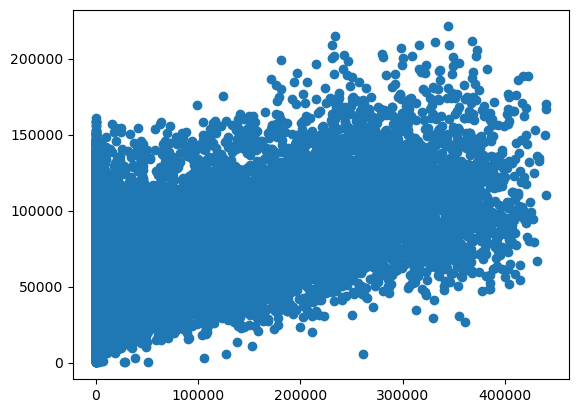

In [79]:
plt.scatter(y[:, -8], y_pred[:, -8])

In [81]:
y.std(dim = 0)

tensor([3.6576e-05, 5.1010e-05, 6.4752e-05, 8.3360e-05, 1.0800e-04, 1.2888e-04,
        1.2104e-04, 9.2297e-05, 5.8875e-05, 4.5326e-05, 3.4526e-05, 2.6513e-05,
        1.9600e-05, 1.4796e-05, 1.0951e-05, 8.6978e-06, 7.9614e-06, 1.0001e-05,
        1.4417e-05, 1.7000e-05, 1.8537e-05, 1.8675e-05, 2.0617e-05, 2.4163e-05,
        2.8605e-05, 3.3721e-05, 3.9633e-05, 4.5187e-05, 5.2035e-05, 5.8935e-05,
        6.4874e-05, 6.9069e-05, 7.1234e-05, 7.3162e-05, 7.5085e-05, 7.4331e-05,
        7.3589e-05, 7.3341e-05, 7.3613e-05, 7.4199e-05, 7.3360e-05, 7.2559e-05,
        7.1240e-05, 7.2097e-05, 7.4106e-05, 7.3414e-05, 7.2601e-05, 7.1325e-05,
        7.0387e-05, 6.7877e-05, 6.6077e-05, 6.5429e-05, 6.3495e-05, 6.1074e-05,
        5.9170e-05, 5.7323e-05, 5.5765e-05, 5.6137e-05, 6.2466e-05, 8.9710e-05,
        9.4532e-18, 6.4227e-18, 2.4742e-18, 2.5736e-19, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        5.4389e-16, 4.7702e-16, 5.2610e-

In [82]:

inp_mean = xr.open_dataset("/glade/u/home/qingyuany/ClimSim/preprocessing/normalizations/inputs/input_mean.nc")
inp_std = xr.open_dataset("/glade/u/home/qingyuany/ClimSim/preprocessing/normalizations/inputs/input_std.nc")
out_mean = xr.open_dataset("/glade/u/home/qingyuany/ClimSim/preprocessing/normalizations/outputs/output_scale.nc")


In [101]:
out_mean['ptend_q0001'].values

array([2834700., 2834700., 2834700., 2834700., 2834700., 2834700.,
       2834700., 2834700., 2834700., 2834700., 2834700., 2834700.,
       2834700., 2834700., 2834700., 2834700., 2834700., 2834700.,
       2834700., 2834700., 2834700., 2834700., 2834700., 2834700.,
       2834700., 2834700., 2834700., 2834700., 2834700., 2834700.,
       2834700., 2834700., 2834700., 2834700., 2834700., 2834700.,
       2834700., 2834700., 2834700., 2834700., 2834700., 2834700.,
       2834700., 2834700., 2834700., 2834700., 2834700., 2834700.,
       2834700., 2834700., 2834700., 2834700., 2834700., 2834700.,
       2834700., 2834700., 2834700., 2834700., 2834700., 2834700.])